In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [5]:
# 1 A)
df = pd.read_csv('/kaggle/input/ad-click-prediction-dataset/ad_click_dataset.csv')

num_rows,num_cols = df.shape
print(F"Number of rows: {num_rows}")
print(F"Number of columns: {num_cols}")

data_types = df.dtypes
print("\ndata types of each column:")
print(data_types)

categorical_vars = df.select_dtypes(include=['object','category']).columns.tolist()
continuous_vars = df.select_dtypes(include=['int64','float64']).columns.tolist()

print("\nCategorical Variables:", categorical_vars)
print("Continuous Variables:", continuous_vars)

Number of rows: 10000
Number of columns: 9

data types of each column:
id                    int64
full_name            object
age                 float64
gender               object
device_type          object
ad_position          object
browsing_history     object
time_of_day          object
click                 int64
dtype: object

Categorical Variables: ['full_name', 'gender', 'device_type', 'ad_position', 'browsing_history', 'time_of_day']
Continuous Variables: ['id', 'age', 'click']


In [6]:
# 1 B)
numerical_columns = df.select_dtypes(include=['int64','float64']).columns
five_point_summary = df[numerical_columns].describe(percentiles=[0.25,0.5,0.75])
print(five_point_summary.loc[['min','25%','50%','75%','max']])

          id   age  click
min      5.0  18.0    0.0
25%   2529.0  29.0    0.0
50%   5218.0  39.5    1.0
75%   7466.0  52.0    1.0
max  10000.0  64.0    1.0


In [7]:
# 1 C)
categorical_columns = df.select_dtypes(include=['object','category']).columns

for col in categorical_columns:
    print(F"Summary for categorical variables:{col}")
    
    num_categories = df[col].nunique()
    print(F"Number of categories:{num_categories}")
    
    category_counts = df[col].value_counts(normalize=True)*100
    print("Percenatge of observations in each category:")
    print(category_counts.to_string())

Summary for categorical variables:full_name
Number of categories:4000
Percenatge of observations in each category:
full_name
User1171     0.25
User6287     0.24
User5100     0.24
User5425     0.23
User8081     0.23
User7266     0.22
User7962     0.22
User2289     0.22
User5574     0.22
User3333     0.21
User3225     0.21
User3042     0.21
User4086     0.21
User1524     0.21
User9842     0.21
User4539     0.20
User8127     0.20
User606      0.20
User8018     0.20
User1136     0.20
User7878     0.20
User6167     0.20
User7        0.20
User4756     0.20
User8726     0.20
User2129     0.19
User2337     0.19
User2311     0.19
User1549     0.19
User4266     0.19
User5329     0.19
User9789     0.19
User5566     0.19
User9418     0.18
User9412     0.18
User1529     0.18
User5418     0.18
User5276     0.18
User9736     0.18
User1141     0.18
User3236     0.18
User1305     0.18
User8459     0.18
User6654     0.18
User6462     0.18
User301      0.18
User3144     0.18
User6248     0.18
User4228   

In [9]:
# 1 D)
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values>0])
print("\n")

numerical_vars = df.select_dtypes(include=['int64','float64'])

print("Outliers detecting (using IQR method):")
for col in numerical_vars.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound = Q1 -1.5*IQR
    upper_bound = Q3+1.5*IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(F"Column '{col}' number of outliers: {outliers.shape[0]}")
print("\n")

id = 'id'

if id in df.columns:
    class_distribution = df[id].value_counts(normalize=True)*100
    print("Class distribution in id variables:")
    print(class_distribution)
    print("\n")

Missing values in each column:
age                 4766
gender              4693
device_type         2000
ad_position         2000
browsing_history    4782
time_of_day         2000
dtype: int64


Outliers detecting (using IQR method):
Column 'id' number of outliers: 0
Column 'age' number of outliers: 0
Column 'click' number of outliers: 0


Class distribution in id variables:
id
1171    0.25
6287    0.24
5100    0.24
5425    0.23
8081    0.23
        ... 
9160    0.01
907     0.01
5957    0.01
1607    0.01
3056    0.01
Name: proportion, Length: 4000, dtype: float64




In [12]:
# 2 A)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn. over_sampling import SMOTE

numerical_vars = df.select_dtypes(include=['int64','float64'])
imputer = SimpleImputer(strategy='mean')
df[numerical_vars.columns] = imputer.fit_transform(numerical_vars)

categorical_vars = df.select_dtypes(include=['object','category'])
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_vars.columns] = imputer_cat.fit_transform(categorical_vars)

print("Missing values handled.")
numerical_vars = df.select_dtypes(include=['int64','float64'])
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQr=Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    df[col] = np.clip(df[col], lower_bound,upper_bound)
print("Outliers handled using capping.")

Missing values handled.
Outliers handled using capping.


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


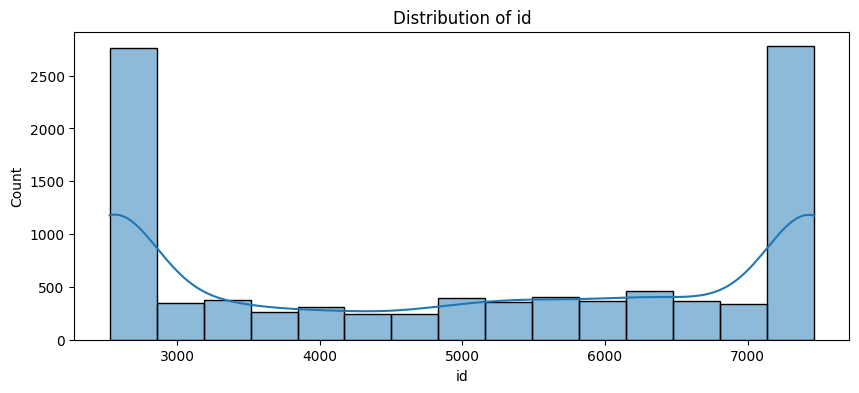

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


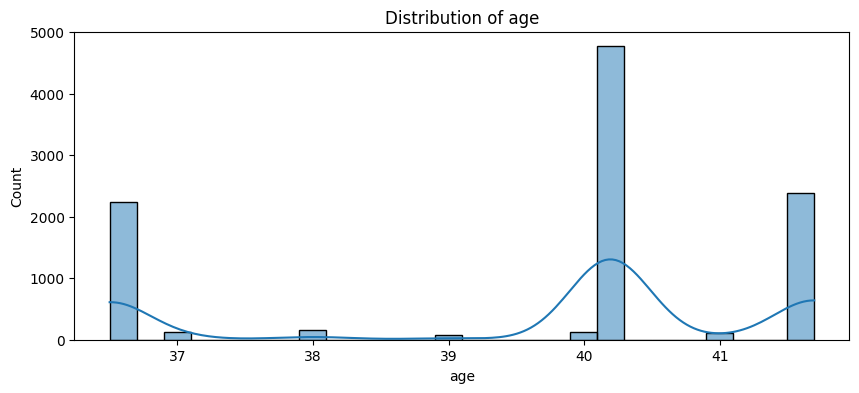

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


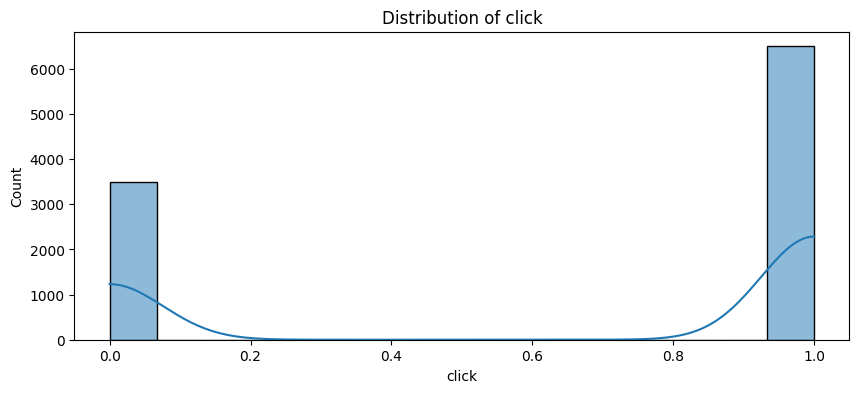

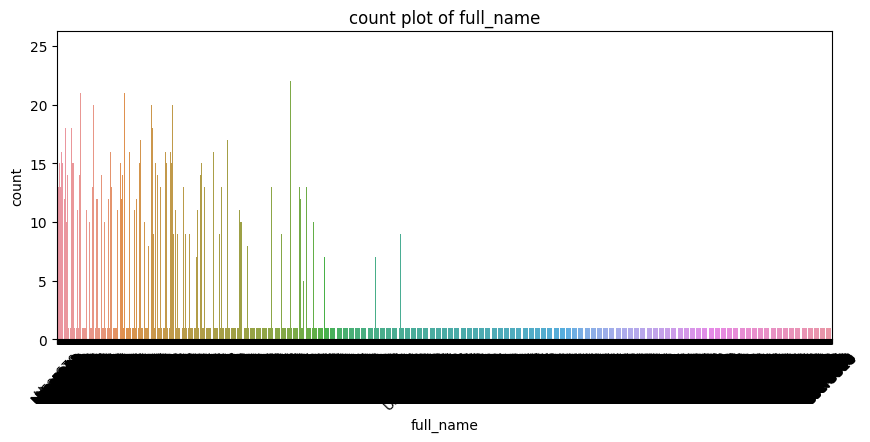

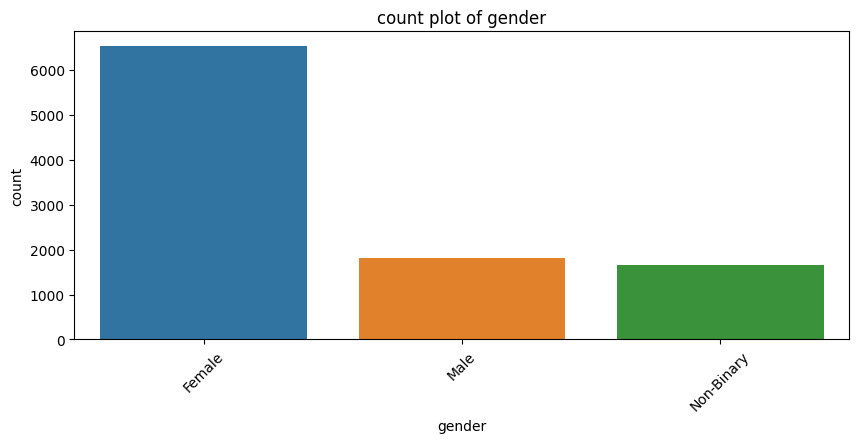

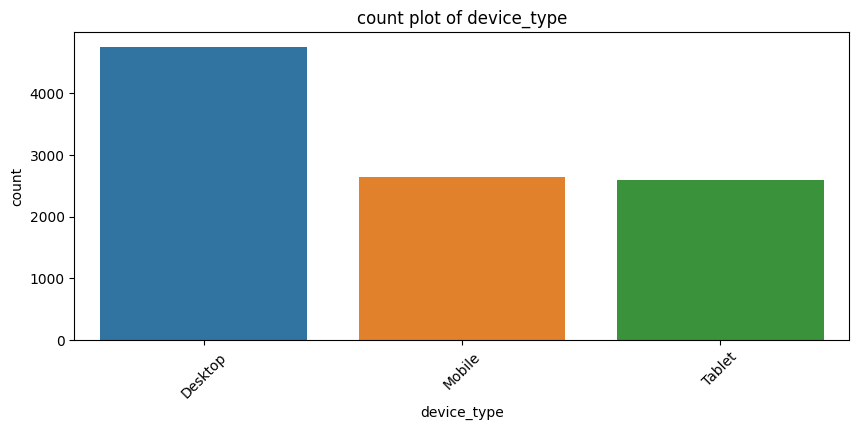

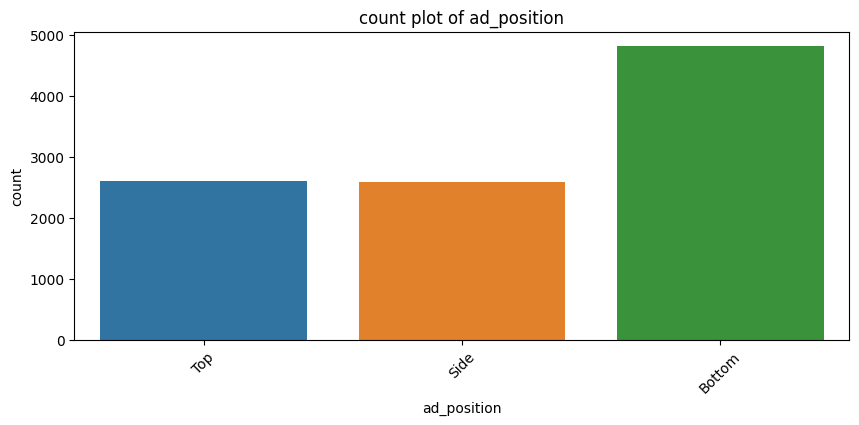

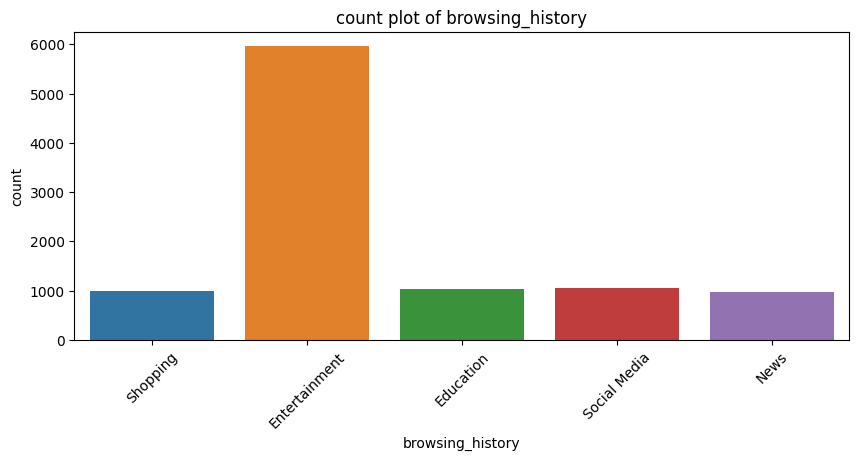

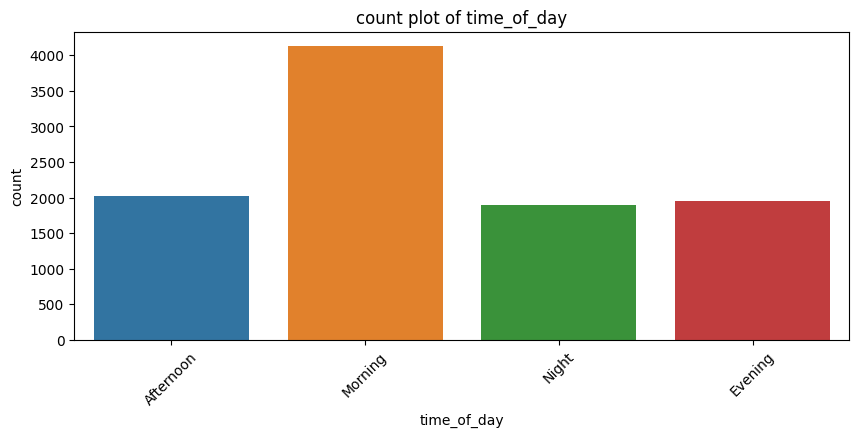

Correlations with id variables:
age      0.010428
click    0.008786
Name: id, dtype: float64


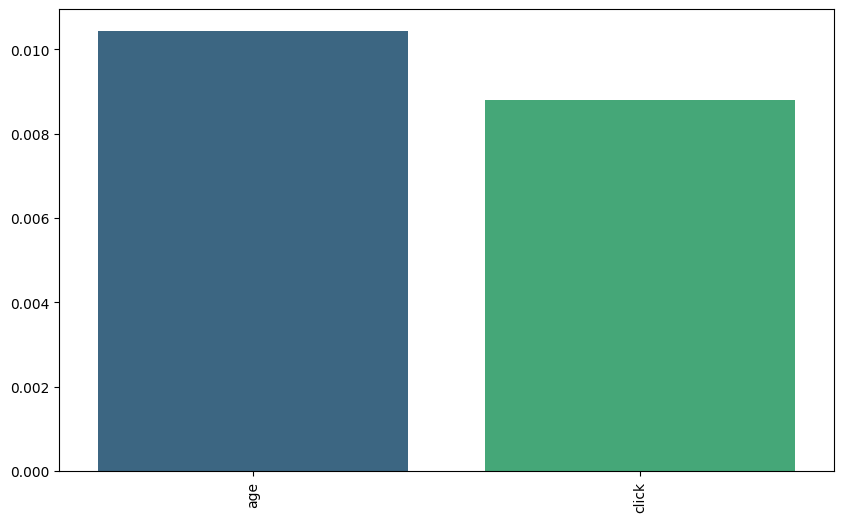

In [13]:
# 2 B)
numerical_vars = df.select_dtypes(include=['int64','float64'])
for col in numerical_vars.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
    
categorical_vars = df.select_dtypes(include=['object','category'])
for col in categorical_vars.columns:
    plt.figure(figsize=(10,4))
    sns.countplot(x=df[col])
    plt.title(F"count plot of {col}")
    plt.xticks(rotation=45)
    plt.show()
    
id = 'id'
if id in df.columns:
    df_numerical = df.select_dtypes(include=['int64','float64'])
    correlations = df_numerical.corr()[id].drop(id)
    
    print("Correlations with id variables:")
    print(correlations.sort_values(ascending=False))
    plt.figure(figsize=(10,6))
    sns.barplot(x=correlations.index,y=correlations.values,palette='viridis')
    plt.xticks(rotation=90)
    plt.show()

In [17]:
# 2 C)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

variables_to_exclude = ['ad_position','browsing_history']
df_cleaned = df.drop(columns=variables_to_exclude)

id = 'id'
if id in df_cleaned.columns:
    x = df_cleaned.drop(columns=[id])
    y = df_cleaned[id]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
    
    scaler = StandardScaler()
    numerical_features = x_train.select_dtypes(include=['int64','float64']).columns
    x_train[numerical_features] = scaler.fit_transform(x_train[numerical_features])
    x_test[numerical_features] = scaler.transform(x_test[numerical_features])
    print("Data preparation complere. the datase is now ready for model creation.")


Data preparation complere. the datase is now ready for model creation.


In [18]:
# 2 D)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_vars = df.select_dtypes(include=['object','category']).columns

label_encoders = {}
for col in categorical_vars:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col]=le
    
print("Label Encoding completed.")

df_encoded = pd.get_dummies(df, columns=categorical_vars,drop_first=True)
print("One-Hot Encoding completed.")

preprocessor = ColumnTransformer(
transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_vars)
],
remainder='passthrough')

x = preprocessor.fit_transform(df)
print("ColumnTransformer completed.")

Label Encoding completed.
One-Hot Encoding completed.
ColumnTransformer completed.


In [25]:
# 2 E)
from sklearn.model_selection import train_test_split
from scipy import stats

id = 'id'
if id in df.columns:
    x = df.drop(columns=[id])
    y=df[id]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    def compare_distribution(df1,df2,columns):
        for col in columns:
            if df1[col].dtype in ['int64','float64']:
                _,p_value = stats.ks_2samp(df1[col],df2[col])
                print(f"Kolmogorov-SMirnov test p-value for {col}: {p_value:.4f}")
                if p_value <0.05:
                    print(F"Distribution of {col} is significantly different between training and testing sets.")
                else:
                    print(F"Distribution of {col} is similar between training and testing sets.")
                    
            else: 
                contingency = pd.crosstab(df1[col],df2[col])
                _,p_value,_,_ = stats.chi2_contingency(contingency)
                print(F"Chi-square test p-value for {col}: {p_value:.4f}")
                if p_value < 0.05:
                    print(F"Diatribution of {col} is significantly different between training and testing sets.")
                else:
                    print(F"Distribution of {col} is similar between training and testing sets.")
    compare_distribution(pd.concat([x_train,y_train],axis=1), pd.concat([x_test,y_test],axis=1),x.columns)

Kolmogorov-SMirnov test p-value for full_name: 0.3269
Distribution of full_name is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for age: 0.9030
Distribution of age is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for gender: 0.8767
Distribution of gender is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for device_type: 0.8064
Distribution of device_type is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for ad_position: 1.0000
Distribution of ad_position is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for browsing_history: 0.4652
Distribution of browsing_history is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for time_of_day: 0.7011
Distribution of time_of_day is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for click: 1.0000
Distribution of click is similar between training and testin

In [26]:
# 3 A)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

id = 'id'
if id in df.columns:
    x=df.drop(columns=[id])
    y=df[id]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    model = LinearRegression()
    model.fit(x_train,y_train)
    
    y_pred = model.predict(x_test)
    mse=mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    
    print(F"Mean squared error of Linear regression model: {mse:.4f}")
    print(F"R^2 scaore of linear regression model:{r2:.4f}")
    
# Key Obseravtions:
# 1) Linear Regression: A fundamental regression technique that models the relationship between dependent and independent variables linearly.
# 2) Baseline performance : Modelserve as a baseline to evaluate more complex algorithims they help establish a performance benchmark.
# 3) Interpretability : coefficient represent  the effect of each feature on the id variable providing clear insight into relationship within the data.
# 4) Computational efficiency: Modela are compuatational effiecient and require less compuatational power compare to more complex models, making them ideal for initial explorations.
# 5) For regression : Mean squared Error(MSE) indicates the average square difference between predicted nd actual values.lower MSe signifies better model performance.
# 6) R^2 score : regression the proportion of variance explained by the model.A highly R^2 value indicates a better fit ti the data.

Mean squared error of Linear regression model: 962856.6893
R^2 scaore of linear regression model:0.7618


In [29]:
# 3 B)
from sklearn.metrics import accuracy_score
y_true = [0,1,1,0,1,0,1,1,0,0]
y_pred = [0,1,0,0,1,0,1,0,0,1]
accuracy = accuracy_score(y_true,y_pred)

print(F"Overall accuracy:{accuracy:.2f}")

if accuracy>= 0.7618:
    print("The accuracy is good.the model is performing well.")
elif 0.60 <=accuracy <0.7618:
        print("The accuarcy is moderate,the model may need improvement.")
else:
    print("The accuracy is low.the model requires significant improvements.")
    
# Key Observations :
# 1) Accuarcy claculations : The accuracy_score functions compares the true lables (y_true) with the predicted labels (y_pred) and calculates the proportion of correct predictions.
# 2) Commentary on accuracy: the code include conditional statement to provide a basic evaluation of the accuracy.
# 3) Good accuracy (>80%) : indicates that the model is performing well.
# 4) Moderate Accuracy(60% to 80%) : suggets that there may be room for improvement.
# 5) Low accuracy(<60%) : Indicates that the model's performance is poor and significant adjustment or differenr approaches might ne needed.

    

Overall accuracy:0.70
The accuarcy is moderate,the model may need improvement.


In [31]:
# 3 C)
from sklearn.metrics import precision_score,recall_score,f1_score,classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

data = load_iris()
x = data.data
y=data.target
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

model = RandomForestClassifier()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

precision = precision_score(y_test,y_pred,average='weighted')
recall = recall_score(y_test,y_pred,average='weighted')
f1 = f1_score(y_test,y_pred,average='weighted')

print('precision:',precision)
print('Recall',recall)
print("f1 scaore:",f1)

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

# Key Observations:
# 1) Precision : Is the ratio of correctly predicted positive observation to the total predicted positives. it is useful when the cpst of false positive is high.
# 2) Recall : (also known as sensitivity) is the ratio of correctly predicted positive observation to all observation in the catual class it is important when the cost of false negative is high.
# 3) F1 Score: Is the harmonic mean of precision and reacll it is a good metric when you need a balance between precision and recall and there is an uneven class distribution
# 4) Choosing the right metric depend on the problem statemment : If false positive are costly ( eg, email spam detection) prioritize precision. if false negative are costly (eg, medical diagnoses),prioritize recall.
#    If you need a balance or if the classes are imabalnced, use f1 score.

precision: 1.0
Recall 1.0
f1 scaore: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



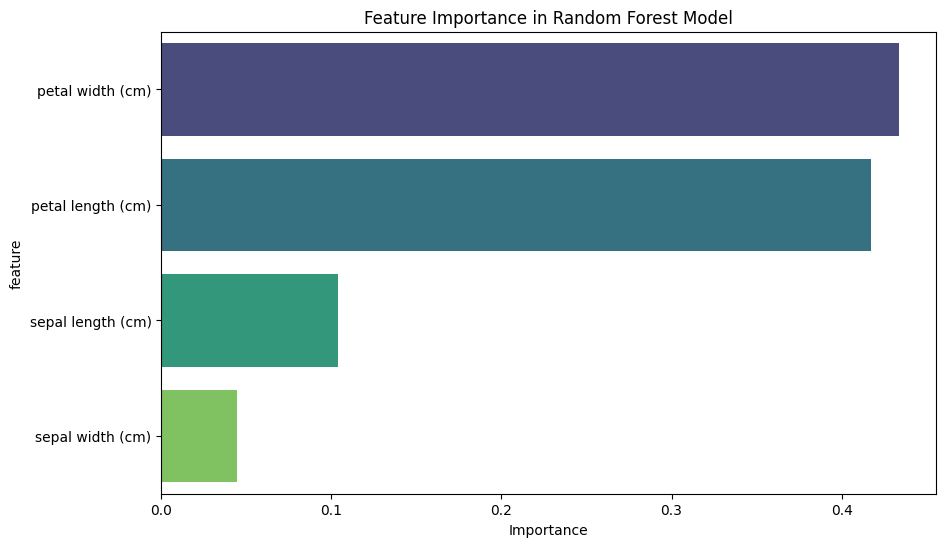

In [40]:
# 3 E)
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = load_iris()
x = pd.DataFrame(data.data,columns=data.feature_names)

y=data.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

feature_importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature':x.columns,
    'Importance': feature_importances
}).sort_values(by='Importance',ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='feature',data=feature_importance_df,palette='viridis')
plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('feature')
plt.show()


# Key Observations:
# Business Interpretation of the model
# 1) Top feature Affecting the id : the bar chart display the most important features influencing the id variables.in this example using the iris dataset,feature like "petal length (CM)" and "Petal width (CM)" have the highest importance, indicating they are the most influential in predicting the target variable (species of the flower)

# 2) Understanding feature relationships: The realationship between the feature and the target can be furhter understood using additional plots such as partial dependence plots or shap values for example if "petal length" has the highest
# 3) Importance, we might examine how changes in petal length impact the predicted probabiltiy of  different flower species.

In [41]:
df.head()

,id,full_name,age,gender,device_type,ad_position,browsing_history,time_of_day,click
0,2527.5,2531,36.500000,0,0,2,3,0,1.0
1,3044.0,911,40.197363,1,0,2,1,2,1.0
2,5912.0,2166,41.000000,2,0,1,0,3,1.0
3,5418.0,1949,36.500000,1,0,0,1,1,1.0
4,7467.5,3748,39.000000,2,0,0,4,2,0.0
